# 04 — Baseline Deep Learning Model (NASA CMAPSS FD001)

**Goal:** Train, validate, and save a baseline deep-learning regression model for
Remaining Useful Life (RUL) prediction, using the fixed-length sequence datasets
produced by Notebook `03_sequence_generation.ipynb`.

**Scope of this notebook**

- Loads the `.npz` sequence datasets produced by Notebook 03 (no regeneration).
- Builds a simple, well-documented `LSTM(128) → LSTM(64) → Dense(32) → Dense(1)`
  baseline architecture.
- Trains with `EarlyStopping` + `ModelCheckpoint` on `val_loss`.
- Evaluates on the validation set for model development, and **once** on the
  test set for final, unbiased reporting.
- Saves the model, training history, metrics, predictions, timing, and
  configuration as reusable artifacts.

**Correctness safeguards in this version:**

- Asserts train/validation/test **engine sets are disjoint** (no engine
  leakage) immediately after loading data.
- Uses **strict, canonical `.npz` keys** (`X`, `y`, `engine_ids`) with no
  silent fallback to alternative naming.
- **Clips negative RUL predictions to 0** everywhere (metrics, saved
  predictions) — RUL cannot be negative.
- Reports the standard **NASA CMAPSS asymmetric scoring function** alongside
  MAE/RMSE/R².
- Runs a lightweight **feature-scaling sanity check** against upstream
  preprocessing, and a **trend-based** (not single-epoch) over/underfitting
  diagnosis.
- Best-effort **op-level determinism** via `tf.config.experimental.enable_op_determinism()`.

**This notebook does NOT:**

- Modify preprocessing (Notebook 01) or feature engineering (Notebook 02).
- Regenerate or reshape sequences (Notebook 03 output is used as-is).
- Fit a new scaler or perform additional feature engineering.
- Use the test set for model selection, epoch selection, or hyperparameter tuning.

The training/evaluation code is written in a modular way so the same framework
can be reused later for GRU, CNN-LSTM, and Transformer variants.


## 1. Imports

Only the libraries needed for data loading, modeling, evaluation, and plotting.

In [2]:
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


TensorFlow version: 2.19.0
NumPy version: 2.1.3
Pandas version: 2.3.0


### Reproducibility

Set a single random seed across `random`, `numpy`, and `tensorflow`. We also
attempt to enable TensorFlow's op-level determinism (`tf.config.experimental.enable_op_determinism`),
which forces deterministic kernels for ops that support it (available on
recent TF versions; some GPU ops still have no deterministic implementation).
If the current TensorFlow build does not support it, we catch the error and
document the limitation instead of failing the notebook.


In [3]:
SEED = 42

def set_global_seed(seed: int = SEED) -> None:
    """Set random seeds for Python, NumPy, and TensorFlow for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_global_seed(SEED)
print(f"Global random seed set to {SEED}")

# Attempt to enable full op-level determinism (TF >= 2.8). This is best-effort:
# some ops (particularly certain GPU kernels) have no deterministic implementation,
# and older TF versions do not expose this API at all.
try:
    tf.config.experimental.enable_op_determinism()
    print("tf.config.experimental.enable_op_determinism() enabled: "
          "deterministic ops requested where supported by this TF build/hardware.")
except AttributeError:
    print(
        "REPRODUCIBILITY LIMITATION: this TensorFlow version does not expose "
        "tf.config.experimental.enable_op_determinism(). Seeds are still set, but "
        "bitwise-identical reruns are not guaranteed (e.g. cuDNN LSTM kernels are "
        "not fully deterministic without it)."
    )
except Exception as e:
    print(
        f"REPRODUCIBILITY LIMITATION: enable_op_determinism() raised {type(e).__name__}: {e}. "
        "Proceeding without full op-level determinism; seeds are still set."
    )


Global random seed set to 42
tf.config.experimental.enable_op_determinism() enabled: deterministic ops requested where supported by this TF build/hardware.


## 2. Project paths

Reuse the existing project structure. Paths are resolved relative to `PROJECT_ROOT`
so the notebook can be executed from top to bottom without manual edits. Only the
`models/trained/dl` and `results/cmapss/dl` output directories are created here —
the input sequence directory is expected to already exist from Notebook 03.


In [4]:
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "sequences"
MODELS_DIR = PROJECT_ROOT / "models" / "trained" / "dl"
RESULTS_DIR = PROJECT_ROOT / "results" / "cmapss" / "dl"

TRAIN_SEQ_PATH = DATA_DIR / "train_sequences.npz"
VAL_SEQ_PATH = DATA_DIR / "validation_sequences.npz"
TEST_SEQ_PATH = DATA_DIR / "test_sequences.npz"

# Create only the output directories. Do NOT create alternative data paths.
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_DIR     : {DATA_DIR}")
print(f"MODELS_DIR   : {MODELS_DIR}")
print(f"RESULTS_DIR  : {RESULTS_DIR}")

for p in (TRAIN_SEQ_PATH, VAL_SEQ_PATH, TEST_SEQ_PATH):
    if not p.exists():
        raise FileNotFoundError(
            f"Expected sequence file not found: {p}\n"
            "This notebook only consumes the output of Notebook 03 "
            "and does not regenerate sequences."
        )
print("All expected sequence files found.")


PROJECT_ROOT : c:\chadha Summer Internship\2nd\Predictive Maintenance
DATA_DIR     : c:\chadha Summer Internship\2nd\Predictive Maintenance\data\sequences
MODELS_DIR   : c:\chadha Summer Internship\2nd\Predictive Maintenance\models\trained\dl
RESULTS_DIR  : c:\chadha Summer Internship\2nd\Predictive Maintenance\results\cmapss\dl
All expected sequence files found.


## 3. Configuration

A single configuration dictionary drives the rest of the notebook. `sequence_length`
and `n_features` are placeholders here (documented as the values reported by
Notebook 02/03 at the time this baseline was written) and are **overwritten from
the loaded arrays** in Section 5 rather than trusted blindly — this keeps the
notebook correct even if the upstream feature-engineering output changes.
`EXPECTED_N_FEATURES_FROM_NOTEBOOK02` is kept as a separate, explicitly-labeled
constant purely for a documentation-and-warning cross-check in Section 5 — it is
never used to drive the model itself.


In [5]:
MODEL_NAME = "baseline_lstm"
TARGET_NAME = "RUL"

# Documented expectation only — this is the feature count Notebook 02's feature
# engineering was last known to produce. It is used solely as a cross-check
# warning in Section 5, never to override the actual loaded array shape.
EXPECTED_N_FEATURES_FROM_NOTEBOOK02 = 225

CONFIG = {
    "seed": SEED,
    "model_name": MODEL_NAME,
    "target_name": TARGET_NAME,

    # Placeholders only — overwritten from the loaded arrays in Section 5.
    "sequence_length": 30,
    "n_features": 225,

    # Training hyperparameters
    "batch_size": 64,
    "epochs": 100,
    "learning_rate": 1e-3,
    "early_stopping_patience": 10,

    # Architecture (baseline only — see Section 6)
    "lstm_units_1": 128,
    "lstm_units_2": 64,
    "dropout_rate": 0.2,
    "dense_units": 32,
}

print(json.dumps(CONFIG, indent=2))


{
  "seed": 42,
  "model_name": "baseline_lstm",
  "target_name": "RUL",
  "sequence_length": 30,
  "n_features": 225,
  "batch_size": 64,
  "epochs": 100,
  "learning_rate": 0.001,
  "early_stopping_patience": 10,
  "lstm_units_1": 128,
  "lstm_units_2": 64,
  "dropout_rate": 0.2,
  "dense_units": 32
}


## 4. Load sequence datasets

Load the three `.npz` archives produced by Notebook 03 and extract `X`, `y`, and
`engine_ids` for each split. Arrays are used exactly as stored — no reshaping or
regeneration.

**Key names are strict.** Only the canonical keys `X`, `y`, and `engine_ids` are
accepted (these are the names Notebook 03 is expected to write). There is no
silent fallback to alternative naming — if a key is missing, `resolve_key()`
raises a clear error naming exactly which key is missing and from which file,
rather than guessing at a differently-named array. This avoids accidentally
pairing the wrong arrays together.

`engine_ids` (one engine identifier per sequence, aligned with `X`/`y`) is
required so that Section 5 can explicitly check for **engine leakage** across
splits.


In [6]:
CANONICAL_KEYS = ("X", "y", "engine_ids")


def resolve_key(data: np.lib.npyio.NpzFile, key: str, npz_path: Path):
    """Strictly resolve a canonical key from a loaded .npz archive.

    Only the canonical key names in CANONICAL_KEYS are accepted. There is no
    fallback to alternative/legacy naming conventions: if the key is missing,
    a clear KeyError is raised naming the missing key and the offending file,
    so a naming mismatch with Notebook 03 fails loudly instead of silently
    pairing mismatched arrays.
    """
    if key not in CANONICAL_KEYS:
        raise ValueError(f"'{key}' is not a canonical key. Expected one of {CANONICAL_KEYS}.")
    if key not in data.files:
        raise KeyError(
            f"Required key '{key}' not found in {npz_path.name}. "
            f"Available keys: {list(data.files)}. "
            f"This notebook only accepts the canonical Notebook 03 output keys "
            f"{CANONICAL_KEYS} — no alternative key names are accepted. "
            f"If Notebook 03 uses different key names, fix Notebook 03's export "
            f"step (or the .npz key names it writes), not this loader."
        )
    return data[key]


def load_sequences(npz_path: Path):
    """Load (X, y, engine_ids) from an .npz file produced by Notebook 03.

    Requires the canonical keys 'X', 'y', 'engine_ids' to be present exactly
    as named — see resolve_key().
    """
    with np.load(npz_path) as data:
        X = resolve_key(data, "X", npz_path)
        y = resolve_key(data, "y", npz_path)
        engine_ids = resolve_key(data, "engine_ids", npz_path)
    return X, y, engine_ids


X_train, y_train, train_engine_ids = load_sequences(TRAIN_SEQ_PATH)
X_validation, y_validation, val_engine_ids = load_sequences(VAL_SEQ_PATH)
X_test, y_test, test_engine_ids = load_sequences(TEST_SEQ_PATH)

print("Loaded shapes:")
print("\nRUL target ranges (sanity check for capping/leakage):")
print(f"  y_train      : min={y_train.min():.2f}, max={y_train.max():.2f}, mean={y_train.mean():.2f}")
print(f"  y_validation : min={y_validation.min():.2f}, max={y_validation.max():.2f}, mean={y_validation.mean():.2f}")
print(f"  y_test       : min={y_test.min():.2f}, max={y_test.max():.2f}, mean={y_test.mean():.2f}")
print(f"  X_train      : {X_train.shape}   | engine_ids: {train_engine_ids.shape}")
print(f"  y_train      : {y_train.shape}")
print(f"  X_validation : {X_validation.shape}   | engine_ids: {val_engine_ids.shape}")
print(f"  y_validation : {y_validation.shape}")
print(f"  X_test       : {X_test.shape}   | engine_ids: {test_engine_ids.shape}")
print(f"  y_test       : {y_test.shape}")


Loaded shapes:

RUL target ranges (sanity check for capping/leakage):
  y_train      : min=0.00, max=125.00, mean=80.81
  y_validation : min=0.00, max=125.00, mean=79.93
  y_test       : min=7.00, max=125.00, mean=74.45
  X_train      : (14241, 30, 225)   | engine_ids: (14241,)
  y_train      : (14241,)
  X_validation : (3490, 30, 225)   | engine_ids: (3490,)
  y_validation : (3490,)
  X_test       : (100, 30, 225)   | engine_ids: (100,)
  y_test       : (100,)


## 5. Verify input data

Structural and numerical checks on the loaded arrays before any modeling happens.
`CONFIG["sequence_length"]` and `CONFIG["n_features"]` are set from the **actual**
loaded arrays here, rather than assumed.


In [7]:
def verify_sequence_data(X_train, y_train, X_validation, y_validation, X_test, y_test, config):
    checks = {}

    # Dimensionality
    checks["X_train is 3D"] = X_train.ndim == 3
    checks["X_validation is 3D"] = X_validation.ndim == 3
    checks["X_test is 3D"] = X_test.ndim == 3
    checks["y_train is 1D"] = y_train.ndim == 1
    checks["y_validation is 1D"] = y_validation.ndim == 1
    checks["y_test is 1D"] = y_test.ndim == 1

    # Sample count alignment
    checks["train samples match (X vs y)"] = X_train.shape[0] == y_train.shape[0]
    checks["validation samples match (X vs y)"] = X_validation.shape[0] == y_validation.shape[0]
    checks["test samples match (X vs y)"] = X_test.shape[0] == y_test.shape[0]

    # Sequence length / feature count consistency across splits
    seq_lengths = {X_train.shape[1], X_validation.shape[1], X_test.shape[1]}
    n_features_set = {X_train.shape[2], X_validation.shape[2], X_test.shape[2]}
    checks["sequence length consistent across splits"] = len(seq_lengths) == 1
    checks["n_features consistent across splits"] = len(n_features_set) == 1

    inferred_seq_len = seq_lengths.pop()
    inferred_n_features = n_features_set.pop()

    # NaN / Inf checks
    for name, arr in [
        ("X_train", X_train), ("y_train", y_train),
        ("X_validation", X_validation), ("y_validation", y_validation),
        ("X_test", X_test), ("y_test", y_test),
    ]:
        arr_f = arr.astype(np.float64)
        checks[f"{name} has no NaN"] = not np.isnan(arr_f).any()
        checks[f"{name} has no Inf"] = not np.isinf(arr_f).any()

    # Dtype suitability for TensorFlow
    for name, arr in [("X_train", X_train), ("X_validation", X_validation), ("X_test", X_test)]:
        checks[f"{name} dtype is floating point"] = np.issubdtype(arr.dtype, np.floating)

    return checks, inferred_seq_len, inferred_n_features


checks, inferred_seq_len, inferred_n_features = verify_sequence_data(
    X_train, y_train, X_validation, y_validation, X_test, y_test, CONFIG
)

# Update configuration from the actual loaded arrays (self-documenting: the
# arrays are always the source of truth, never a hard-coded number).
CONFIG["sequence_length"] = int(inferred_seq_len)
CONFIG["n_features"] = int(inferred_n_features)

print("Verification summary")
print("-" * 50)
all_passed = True
for check_name, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_passed = False
    print(f"[{status}] {check_name}")
print("-" * 50)

if not all_passed:
    raise ValueError("One or more data verification checks failed. See summary above.")

print("All checks passed.")
print(f"Confirmed sequence_length = {CONFIG['sequence_length']}, n_features = {CONFIG['n_features']}")

# Self-documenting cross-check (warning only, not a hard failure): compare the
# actually-loaded feature count against the count Notebook 02's feature
# engineering was last documented to produce. A mismatch does not block this
# notebook (the loaded arrays are always authoritative), but it is surfaced
# loudly since it likely indicates Notebook 02 or 03 changed upstream.
if CONFIG["n_features"] != EXPECTED_N_FEATURES_FROM_NOTEBOOK02:
    print(
        f"\nWARNING: loaded n_features ({CONFIG['n_features']}) does not match the "
        f"documented Notebook 02 output ({EXPECTED_N_FEATURES_FROM_NOTEBOOK02}). "
        "This notebook will still proceed using the actual loaded shape, but you "
        "should confirm this change in feature count is intentional (e.g. Notebook "
        "02's feature engineering was updated) and not a data pipeline bug."
    )
else:
    print(
        f"\nFeature count cross-check OK: loaded n_features ({CONFIG['n_features']}) "
        f"matches the documented Notebook 02 output ({EXPECTED_N_FEATURES_FROM_NOTEBOOK02})."
    )


Verification summary
--------------------------------------------------
[PASS] X_train is 3D
[PASS] X_validation is 3D
[PASS] X_test is 3D
[PASS] y_train is 1D
[PASS] y_validation is 1D
[PASS] y_test is 1D
[PASS] train samples match (X vs y)
[PASS] validation samples match (X vs y)
[PASS] test samples match (X vs y)
[PASS] sequence length consistent across splits
[PASS] n_features consistent across splits
[PASS] X_train has no NaN
[PASS] X_train has no Inf
[PASS] y_train has no NaN
[PASS] y_train has no Inf
[PASS] X_validation has no NaN
[PASS] X_validation has no Inf
[PASS] y_validation has no NaN
[PASS] y_validation has no Inf
[PASS] X_test has no NaN
[PASS] X_test has no Inf
[PASS] y_test has no NaN
[PASS] y_test has no Inf
[PASS] X_train dtype is floating point
[PASS] X_validation dtype is floating point
[PASS] X_test dtype is floating point
--------------------------------------------------
All checks passed.
Confirmed sequence_length = 30, n_features = 225

Feature count cross-ch

In [8]:
# Cast to float32 for TensorFlow (no reshaping, no re-scaling — dtype only).
X_train = X_train.astype(np.float32)
X_validation = X_validation.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_validation = y_validation.astype(np.float32)
y_test = y_test.astype(np.float32)

print("Dtypes after casting:")
print(f"  X_train: {X_train.dtype}, y_train: {y_train.dtype}")


Dtypes after casting:
  X_train: float32, y_train: float32


### Engine leakage check

A subtle but critical failure mode for CMAPSS-style data: if the same engine's
cycles appear in more than one split, the model can effectively "see" part of
an engine's degradation trajectory during training and be evaluated on the
rest of that same engine — inflating validation/test performance in a way
that will not generalize.

We explicitly assert that the three splits contain **disjoint sets of engine
IDs**. If this fails, it means Notebook 03's train/validation/test split was
not done at the engine level. **This must be fixed in Notebook 03** (the
engine-level split logic) — it must not be patched around here (e.g. by
silently dropping overlapping engines), since that would hide a bug in the
upstream splitting rather than fixing it, and would also silently change
which data this baseline is evaluated on.


In [9]:
train_engine_set = set(np.asarray(train_engine_ids).ravel().tolist())
val_engine_set = set(np.asarray(val_engine_ids).ravel().tolist())
test_engine_set = set(np.asarray(test_engine_ids).ravel().tolist())

print(f"Unique engines — train: {len(train_engine_set)}, "
      f"validation: {len(val_engine_set)}, test: {len(test_engine_set)}")

train_val_overlap = train_engine_set & val_engine_set
train_test_overlap = train_engine_set & test_engine_set
val_test_overlap = val_engine_set & test_engine_set

assert train_engine_set.isdisjoint(val_engine_set), (
    f"Engine leakage detected: train and validation contain overlapping engines "
    f"({sorted(train_val_overlap)}). This must be fixed in Notebook 03's "
    f"engine-level train/validation split — do not filter or deduplicate "
    f"engines here in Notebook 04."
)
assert train_engine_set.isdisjoint(test_engine_set), (
    f"Engine leakage detected: train and test contain overlapping engines "
    f"({sorted(train_test_overlap)}). This must be fixed in Notebook 03's "
    f"engine-level train/test split — do not filter or deduplicate engines "
    f"here in Notebook 04."
)
assert val_engine_set.isdisjoint(test_engine_set), (
    f"Engine leakage detected: validation and test contain overlapping engines "
    f"({sorted(val_test_overlap)}). This must be fixed in Notebook 03's "
    f"engine-level validation/test split — do not filter or deduplicate "
    f"engines here in Notebook 04."
)

print("No engine leakage detected: train, validation, and test engine sets are pairwise disjoint.")


Unique engines — train: 80, validation: 20, test: 100
No engine leakage detected: train, validation, and test engine sets are pairwise disjoint.


### Feature scaling sanity check

A lightweight cross-check (not a hard gate) against the scaling applied in
earlier notebooks: if features were standard-scaled upstream, per-feature
means/stds pooled across all timesteps and samples should be roughly `0`/`1`.
This is only a sanity check on `X_train` — it does not refit or modify any
scaler, and a mismatch only prints a warning for follow-up rather than
stopping the notebook (different legitimate scaling choices, e.g. min-max,
would also fail a mean≈0/std≈1 check without being wrong).


In [10]:
def check_feature_scaling(X: np.ndarray, name: str = "X_train",
                           mean_tol: float = 0.5, std_low: float = 0.5, std_high: float = 2.0):
    """Lightweight cross-check that features look plausibly scaled.

    Computes per-feature mean/std pooled across samples and timesteps, then
    checks whether the *average* feature mean/std falls near the range
    expected for standard-scaled data (mean ~ 0, std ~ 1). This is a coarse
    sanity check against previous preprocessing notebooks, not a strict
    contract — it only warns, it never modifies the data.
    """
    flat = X.reshape(-1, X.shape[-1])
    feature_means = flat.mean(axis=0)
    feature_stds = flat.std(axis=0)

    avg_abs_mean = float(np.mean(np.abs(feature_means)))
    avg_std = float(np.mean(feature_stds))

    looks_standard_scaled = (avg_abs_mean <= mean_tol) and (std_low <= avg_std <= std_high)

    print(f"[{name}] avg |feature mean| = {avg_abs_mean:.4f}, avg feature std = {avg_std:.4f}")
    if looks_standard_scaled:
        print(f"[{name}] Features look consistent with standard scaling from earlier notebooks.")
    else:
        print(
            f"WARNING [{name}]: feature statistics do not look like standard-scaled data "
            f"(expected avg |mean| <= {mean_tol} and avg std in [{std_low}, {std_high}]). "
            "This may be expected if a different scaler was used upstream (e.g. min-max), "
            "but if standard scaling was expected, verify Notebook 02's scaler was applied "
            "consistently to this split."
        )
    return avg_abs_mean, avg_std, looks_standard_scaled


_ = check_feature_scaling(X_train, name="X_train")


[X_train] avg |feature mean| = 0.4307, avg feature std = 0.1057
WARNING [X_train]: feature statistics do not look like standard-scaled data (expected avg |mean| <= 0.5 and avg std in [0.5, 2.0]). This may be expected if a different scaler was used upstream (e.g. min-max), but if standard scaling was expected, verify Notebook 02's scaler was applied consistently to this split.


## 6. Build baseline DL regression model

A deliberately simple, stacked-LSTM regressor:

```text
Input(sequence_length, n_features)
  ↓
LSTM(128, return_sequences=True)   — learns short/medium-term temporal patterns,
                                      passes the full sequence forward
  ↓
Dropout(0.2)                       — regularization to reduce overfitting
  ↓
LSTM(64)                           — compresses temporal information into a
                                      single fixed-length representation
  ↓
Dropout(0.2)                       — regularization
  ↓
Dense(32, activation="relu")       — non-linear feature combination
  ↓
Dense(1)                           — scalar RUL regression output
```

This is intentionally a **baseline**: no bidirectional layers, attention,
transformers, or CNN blocks. The `build_model` function is written to be
reusable — later notebooks (GRU, CNN-LSTM, Transformer) can follow the same
`build → compile → train → evaluate → save` structure.


In [11]:
def build_baseline_lstm_model(sequence_length: int, n_features: int, config: dict) -> keras.Model:
    """Build the baseline stacked-LSTM regression model for RUL prediction.

    Architecture:
        Input -> LSTM(128) -> Dropout(0.2) -> LSTM(64) -> Dropout(0.2)
              -> Dense(32, relu) -> Dense(1)
    """
    inputs = keras.Input(shape=(sequence_length, n_features), name="sequence_input")

    x = layers.LSTM(
        config["lstm_units_1"], return_sequences=True, name="lstm_1"
    )(inputs)
    x = layers.Dropout(config["dropout_rate"], name="dropout_1")(x)

    x = layers.LSTM(config["lstm_units_2"], name="lstm_2")(x)
    x = layers.Dropout(config["dropout_rate"], name="dropout_2")(x)

    x = layers.Dense(config["dense_units"], activation="relu", name="dense_hidden")(x)
    outputs = layers.Dense(1, name="rul_output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name=config["model_name"])
    return model


model = build_baseline_lstm_model(
    sequence_length=CONFIG["sequence_length"],
    n_features=CONFIG["n_features"],
    config=CONFIG,
)

# Sanity-check the expected input/output shapes.
assert model.input_shape == (None, CONFIG["sequence_length"], CONFIG["n_features"])
assert model.output_shape == (None, 1)
print(f"Model input shape : {model.input_shape}")
print(f"Model output shape: {model.output_shape}")


Model input shape : (None, 30, 225)
Model output shape: (None, 1)


## 7. Compile model

Adam optimizer with a configurable learning rate, MSE loss (standard for RUL
regression), and MAE tracked as an additional, more interpretable metric.
The test set is not involved in this step.


In [12]:
optimizer = keras.optimizers.Adam(learning_rate=CONFIG["learning_rate"])

model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"],
)

model.summary()

trainable_params = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
non_trainable_params = int(np.sum([np.prod(v.shape) for v in model.non_trainable_weights]))
total_params = trainable_params + non_trainable_params

print(f"\nTrainable parameters    : {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")
print(f"Total parameters        : {total_params:,}")


Model: "baseline_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)     │ (None, 30, 225)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │       181,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rul_output (Dense)              │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,769 (909.25 KB)

 Trainable params: 232,769 (909.25 KB)

 Non-trainable params: 0 (0.00 B)


Trainable parameters    : 232,769
Non-trainable parameters: 0
Total parameters        : 232,769


## 8. Train model

Trained on `(X_train, y_train)` with `(X_validation, y_validation)` used for
monitoring only. `EarlyStopping` and `ModelCheckpoint` both watch `val_loss`.
The test set is never passed to `model.fit`.


In [13]:
CHECKPOINT_PATH = MODELS_DIR / f"{MODEL_NAME}_best.keras"

early_stopping_cb = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=CONFIG["early_stopping_patience"],
    restore_best_weights=True,
    verbose=1,
)

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath=str(CHECKPOINT_PATH),
    monitor="val_loss",
    save_best_only=True,
    verbose=1,
)

callbacks = [early_stopping_cb, checkpoint_cb]

start_time = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_validation, y_validation),
    batch_size=CONFIG["batch_size"],
    epochs=CONFIG["epochs"],
    callbacks=callbacks,
    verbose=1,
)

training_time_seconds = time.time() - start_time

print(f"\nTraining completed in {training_time_seconds:.2f} seconds "
      f"({training_time_seconds / 60:.2f} minutes).")
print(f"Best model checkpoint saved to: {CHECKPOINT_PATH}")


Epoch 1/100
221/223 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 3886.3298 - mae: 52.4942
Epoch 1: val_loss improved from None to 1744.73877, saving model to c:\chadha Summer Internship\2nd\Predictive Maintenance\models\trained\dl\baseline_lstm_best.keras

Epoch 1: finished saving model to c:\chadha Summer Internship\2nd\Predictive Maintenance\models\trained\dl\baseline_lstm_best.keras
223/223 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 3872.0056 - mae: 52.3900 - val_loss: 1744.7388 - val_mae: 37.1664
Epoch 2/100
221/223 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1773.4180 - mae: 37.3315
Epoch 2: val_loss improved from 1744.73877 to 1743.40479, saving model to c:\chadha Summer Internship\2nd\Predictive Maintenance\models\trained\dl\baseline_lstm_best.keras

Epoch 2: finished saving model to c:\chadha Summer Internship\2nd\Predictive Maintenance\models\trained\dl\baseline_lstm_best.keras
223/223 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 1773.0273 - mae: 37.3261 - val_loss: 1743.4048 - val_mae

## 9. Analyze training history

Plot loss and MAE curves for train vs. validation, identify the best epoch,
and give a brief fit diagnosis (well-fitted / underfitted / overfitted) based
on the **trend** of the last several epochs rather than a single-epoch snapshot.


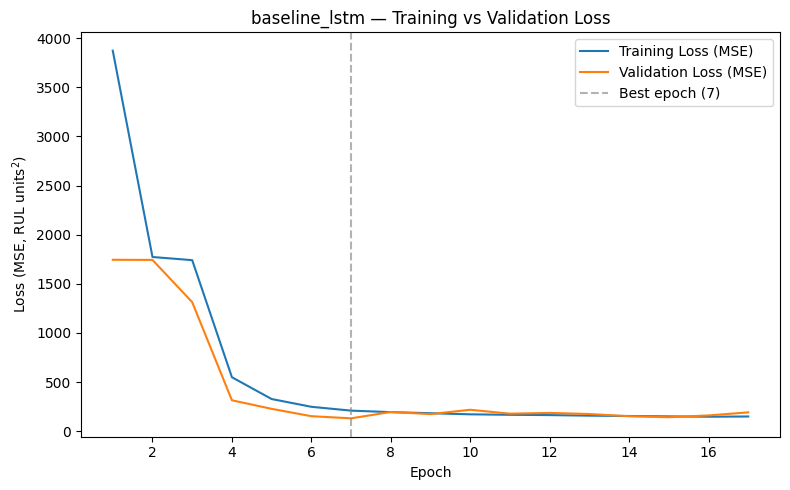

Saved: c:\chadha Summer Internship\2nd\Predictive Maintenance\results\cmapss\dl\baseline_lstm_loss_curve.png


In [14]:
history_dict = history.history
epochs_range = range(1, len(history_dict["loss"]) + 1)

best_epoch = int(np.argmin(history_dict["val_loss"])) + 1
best_val_loss = float(np.min(history_dict["val_loss"]))
best_val_mae = float(history_dict["val_mae"][best_epoch - 1])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs_range, history_dict["loss"], label="Training Loss (MSE)")
ax.plot(epochs_range, history_dict["val_loss"], label="Validation Loss (MSE)")
ax.axvline(best_epoch, color="gray", linestyle="--", alpha=0.6, label=f"Best epoch ({best_epoch})")
ax.set_title(f"{MODEL_NAME} — Training vs Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (MSE, RUL units$^2$)")
ax.legend()
fig.tight_layout()
loss_plot_path = RESULTS_DIR / f"{MODEL_NAME}_loss_curve.png"
fig.savefig(loss_plot_path, dpi=150)
plt.show()
print(f"Saved: {loss_plot_path}")


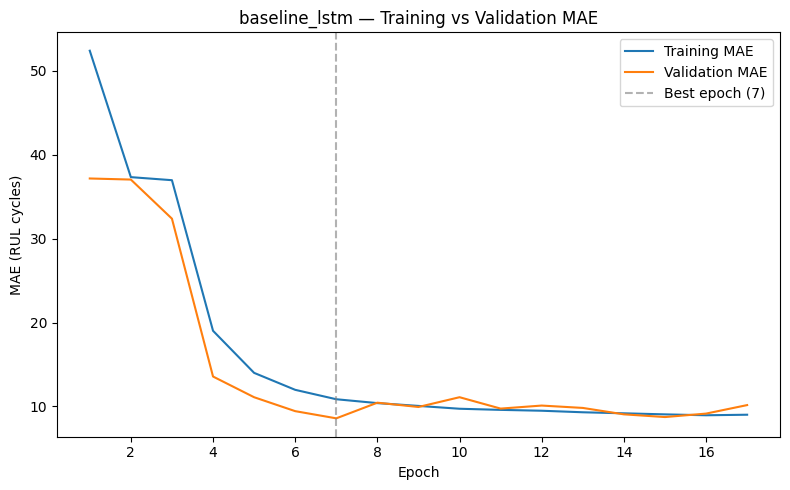

Saved: c:\chadha Summer Internship\2nd\Predictive Maintenance\results\cmapss\dl\baseline_lstm_mae_curve.png


In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs_range, history_dict["mae"], label="Training MAE")
ax.plot(epochs_range, history_dict["val_mae"], label="Validation MAE")
ax.axvline(best_epoch, color="gray", linestyle="--", alpha=0.6, label=f"Best epoch ({best_epoch})")
ax.set_title(f"{MODEL_NAME} — Training vs Validation MAE")
ax.set_xlabel("Epoch")
ax.set_ylabel("MAE (RUL cycles)")
ax.legend()
fig.tight_layout()
mae_plot_path = RESULTS_DIR / f"{MODEL_NAME}_mae_curve.png"
fig.savefig(mae_plot_path, dpi=150)
plt.show()
print(f"Saved: {mae_plot_path}")


In [16]:
print(f"Best epoch           : {best_epoch}")
print(f"Best validation loss  (MSE): {best_val_loss:.4f}")
print(f"Best validation MAE         : {best_val_mae:.4f}")


def diagnose_fit_trend(history_dict: dict, n_recent: int = 5, flat_slope_tol: float = 1e-3):
    """Trend-based fit diagnosis over the last `n_recent` recorded epochs.

    Rather than comparing train/val loss at a single epoch, this fits a linear
    trend (slope) to the last n_recent epochs of training loss and validation
    loss separately, then classifies the run as:

      - overfitted : val loss trending up while train loss is flat/decreasing
                     over the recent window
      - underfitted: both train and val loss are still trending down (or flat
                     at a high level) with no sign of validation loss turning
                     the corner
      - well-fitted : train and val loss both roughly flat/decreasing and
                      close together, i.e. neither of the above patterns holds

    Uses whatever epochs were actually recorded (post EarlyStopping), not just
    the epoch with the single best val_loss.
    """
    train_loss = np.asarray(history_dict["loss"], dtype=np.float64)
    val_loss = np.asarray(history_dict["val_loss"], dtype=np.float64)

    n = min(n_recent, len(train_loss))
    if n < 3:
        return (
            "not enough epochs to assess a trend (fewer than 3 recorded) — "
            "treat this baseline's fit as inconclusive",
            None, None,
        )

    x = np.arange(n)
    recent_train = train_loss[-n:]
    recent_val = val_loss[-n:]

    train_slope = float(np.polyfit(x, recent_train, 1)[0])
    val_slope = float(np.polyfit(x, recent_val, 1)[0])

    if val_slope > flat_slope_tol and train_slope <= flat_slope_tol:
        diagnosis = (
            f"possibly overfitted — over the last {n} epochs, validation loss is "
            f"trending up (slope={val_slope:+.5f}/epoch) while training loss is "
            f"flat or still decreasing (slope={train_slope:+.5f}/epoch)"
        )
    elif train_slope < -flat_slope_tol and val_slope < -flat_slope_tol:
        diagnosis = (
            f"possibly underfitted — both training loss (slope={train_slope:+.5f}/epoch) "
            f"and validation loss (slope={val_slope:+.5f}/epoch) are still decreasing "
            f"over the last {n} epochs, suggesting more training/capacity may help"
        )
    else:
        diagnosis = (
            f"well-fitted — over the last {n} epochs, training loss "
            f"(slope={train_slope:+.5f}/epoch) and validation loss "
            f"(slope={val_slope:+.5f}/epoch) show no consistent divergent or "
            f"steadily-decreasing pattern"
        )
    return diagnosis, train_slope, val_slope


fit_diagnosis, recent_train_slope, recent_val_slope = diagnose_fit_trend(history_dict, n_recent=5)
print(f"\nFit diagnosis (trend-based, last up to 5 epochs): {fit_diagnosis}")


Best epoch           : 7
Best validation loss  (MSE): 131.4100
Best validation MAE         : 8.5867

Fit diagnosis (trend-based, last up to 5 epochs): possibly overfitted — over the last 5 epochs, validation loss is trending up (slope=+4.19616/epoch) while training loss is flat or still decreasing (slope=-2.42059/epoch)


## 10. Evaluate on validation set

Evaluate the best model (weights restored by `EarlyStopping`, and also persisted
to disk by `ModelCheckpoint`) on the validation set. This is used for model
development and selection — **not** the test set.

Two corrections are applied consistently to every prediction from this point
on:

- **Negative RUL clipping**: raw regression output can be negative, which is
  physically meaningless for Remaining Useful Life. Predictions are clipped
  to `>= 0` with `np.maximum(y_pred, 0)` immediately after `model.predict`,
  and the **clipped** predictions are what feed MAE/RMSE/R²/the NASA score
  and what gets saved to disk.
- **NASA CMAPSS asymmetric scoring function**: reported alongside MAE/RMSE/R²
  as the standard CMAPSS benchmark score, which penalizes late predictions
  (predicting more life than the engine actually has) more heavily than early
  predictions — matching the real safety cost asymmetry of RUL estimation.


In [17]:
def cmapss_score(y_true, y_pred):
    """Standard NASA CMAPSS asymmetric RUL scoring function (lower is better).

    For d = y_pred - y_true (predicted minus actual RUL):
      - d < 0 (early prediction, predicted RUL below actual): score = exp(-d/13) - 1
      - d >= 0 (late prediction, predicted RUL above actual): score = exp(d/10) - 1

    Late predictions are penalized more heavily (faster-growing exponential,
    denominator 10 vs 13) since predicting more remaining life than an engine
    actually has is the more dangerous error in a maintenance setting. This is
    the standard scoring function used in the NASA CMAPSS literature/benchmarks.
    """
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0)
    return float(np.sum(score))


def regression_metrics(y_true, y_pred):
    """Compute MAE, RMSE, R^2, and the NASA CMAPSS score consistently for
    validation and test evaluation. Assumes y_pred has already been clipped
    to be non-negative (RUL cannot be negative) by the caller.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)
    nasa_score = cmapss_score(y_true, y_pred)
    return {"mae": float(mae), "rmse": rmse, "r2": float(r2), "nasa_score": nasa_score}


y_validation_pred_raw = model.predict(X_validation, verbose=0).ravel()
# RUL cannot be negative — clip immediately, and use the clipped predictions
# consistently for every downstream metric and saved artifact.
y_validation_pred = np.maximum(y_validation_pred_raw, 0)
n_clipped_validation = int(np.sum(y_validation_pred_raw < 0))

validation_metrics = regression_metrics(y_validation, y_validation_pred)

print(
    "\nNOTE: validation NASA score is NOT comparable to the test NASA score or to "
    "published CMAPSS benchmarks -- validation contains many sliding windows per "
    "engine (not just the final cycle), so its score sums over a different sample "
    "population/size than the standard 100-engine, one-window-per-engine test "
    "evaluation. Use this validation NASA score only as a relative training "
    "diagnostic, and quote the TEST NASA score for reporting."
)

print(f"Clipped {n_clipped_validation} negative validation prediction(s) to 0 "
      f"(out of {len(y_validation_pred_raw)}).")
print("Validation metrics:")
for k, v in validation_metrics.items():
    print(f"  {k.upper():5s}: {v:.4f}")

validation_predictions_df = pd.DataFrame({
    "y_true": y_validation,
    "y_pred": y_validation_pred,
    "abs_error": np.abs(y_validation - y_validation_pred),
})

validation_predictions_path = RESULTS_DIR / f"{MODEL_NAME}_validation_predictions.csv"
validation_predictions_df.to_csv(validation_predictions_path, index=False)

validation_metrics_path = MODELS_DIR / f"{MODEL_NAME}_validation_metrics.json"
with open(validation_metrics_path, "w") as f:
    json.dump(validation_metrics, f, indent=2)

print(f"\nSaved: {validation_predictions_path}")
print(f"Saved: {validation_metrics_path}")



NOTE: validation NASA score is NOT comparable to the test NASA score or to published CMAPSS benchmarks -- validation contains many sliding windows per engine (not just the final cycle), so its score sums over a different sample population/size than the standard 100-engine, one-window-per-engine test evaluation. Use this validation NASA score only as a relative training diagnostic, and quote the TEST NASA score for reporting.
Clipped 0 negative validation prediction(s) to 0 (out of 3490).
Validation metrics:
  MAE  : 8.5867
  RMSE : 11.4634
  R2   : 0.9246
  NASA_SCORE: 6071.4742

Saved: c:\chadha Summer Internship\2nd\Predictive Maintenance\results\cmapss\dl\baseline_lstm_validation_predictions.csv
Saved: c:\chadha Summer Internship\2nd\Predictive Maintenance\models\trained\dl\baseline_lstm_validation_metrics.json


## 11. Final test evaluation

The model, architecture, and training configuration are now finalized. The best
saved model is evaluated on the test set **exactly once**, purely for reporting.
Test performance is not used anywhere above this point to select epochs, tune
hyperparameters, or choose between architectures.


In [18]:
# Load the best-checkpointed model from disk to make sure we are evaluating the
# exact artifact that will be saved/shipped, independent of in-memory state.
best_model = keras.models.load_model(CHECKPOINT_PATH)

y_test_pred_raw = best_model.predict(X_test, verbose=0).ravel()
# RUL cannot be negative — clip immediately, consistent with validation.
y_test_pred = np.maximum(y_test_pred_raw, 0)
n_clipped_test = int(np.sum(y_test_pred_raw < 0))

test_metrics = regression_metrics(y_test, y_test_pred)

print(f"Clipped {n_clipped_test} negative test prediction(s) to 0 "
      f"(out of {len(y_test_pred_raw)}).")
print("Final TEST metrics (evaluated once, for reporting only):")
for k, v in test_metrics.items():
    print(f"  {k.upper():5s}: {v:.4f}")

test_predictions_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_test_pred,
    "abs_error": np.abs(y_test - y_test_pred),
})

test_predictions_path = RESULTS_DIR / f"{MODEL_NAME}_test_predictions.csv"
test_predictions_df.to_csv(test_predictions_path, index=False)

test_metrics_path = MODELS_DIR / f"{MODEL_NAME}_test_metrics.json"
with open(test_metrics_path, "w") as f:
    json.dump(test_metrics, f, indent=2)

print(f"\nSaved: {test_predictions_path}")
print(f"Saved: {test_metrics_path}")


Clipped 0 negative test prediction(s) to 0 (out of 100).
Final TEST metrics (evaluated once, for reporting only):
  MAE  : 9.6654
  RMSE : 13.3490
  R2   : 0.8890
  NASA_SCORE: 264.2873

Saved: c:\chadha Summer Internship\2nd\Predictive Maintenance\results\cmapss\dl\baseline_lstm_test_predictions.csv
Saved: c:\chadha Summer Internship\2nd\Predictive Maintenance\models\trained\dl\baseline_lstm_test_metrics.json


## 12. Save model and artifacts

Persist everything needed to reproduce or audit this run: the best model,
training history, both metric sets, both prediction sets, timing, configuration,
and a summary of the architecture.


In [19]:
# 1) Best model (already saved during training by ModelCheckpoint; re-save to be explicit)
best_model.save(CHECKPOINT_PATH)

# 2) Training history
history_path = MODELS_DIR / f"{MODEL_NAME}_history.json"
history_serializable = {k: [float(x) for x in v] for k, v in history_dict.items()}
with open(history_path, "w") as f:
    json.dump(history_serializable, f, indent=2)

# 3) Training time
timing_path = MODELS_DIR / f"{MODEL_NAME}_timing.json"
with open(timing_path, "w") as f:
    json.dump({
        "training_time_seconds": training_time_seconds,
        "training_time_minutes": training_time_seconds / 60,
        "epochs_run": len(history_dict["loss"]),
        "best_epoch": best_epoch,
    }, f, indent=2)

# 4) Model configuration
config_path = MODELS_DIR / f"{MODEL_NAME}_config.json"
with open(config_path, "w") as f:
    json.dump(CONFIG, f, indent=2)

# 5) Model summary / architecture information
summary_lines = []
best_model.summary(print_fn=lambda line: summary_lines.append(line))
summary_path = MODELS_DIR / f"{MODEL_NAME}_summary.json"
with open(summary_path, "w") as f:
    json.dump({
        "model_name": best_model.name,
        "input_shape": [None if d is None else int(d) for d in best_model.input_shape],
        "output_shape": [None if d is None else int(d) for d in best_model.output_shape],
        "total_params": total_params,
        "trainable_params": trainable_params,
        "non_trainable_params": non_trainable_params,
        "layers": [layer.name for layer in best_model.layers],
        "text_summary": summary_lines,
    }, f, indent=2)

saved_files = [
    CHECKPOINT_PATH, history_path, validation_metrics_path, test_metrics_path,
    validation_predictions_path, test_predictions_path, timing_path,
    config_path, summary_path,
]

print("Saved artifacts:")
for p in saved_files:
    print(f"  - {p}")


Saved artifacts:
  - c:\chadha Summer Internship\2nd\Predictive Maintenance\models\trained\dl\baseline_lstm_best.keras
  - c:\chadha Summer Internship\2nd\Predictive Maintenance\models\trained\dl\baseline_lstm_history.json
  - c:\chadha Summer Internship\2nd\Predictive Maintenance\models\trained\dl\baseline_lstm_validation_metrics.json
  - c:\chadha Summer Internship\2nd\Predictive Maintenance\models\trained\dl\baseline_lstm_test_metrics.json
  - c:\chadha Summer Internship\2nd\Predictive Maintenance\results\cmapss\dl\baseline_lstm_validation_predictions.csv
  - c:\chadha Summer Internship\2nd\Predictive Maintenance\results\cmapss\dl\baseline_lstm_test_predictions.csv
  - c:\chadha Summer Internship\2nd\Predictive Maintenance\models\trained\dl\baseline_lstm_timing.json
  - c:\chadha Summer Internship\2nd\Predictive Maintenance\models\trained\dl\baseline_lstm_config.json
  - c:\chadha Summer Internship\2nd\Predictive Maintenance\models\trained\dl\baseline_lstm_summary.json


## 13. Final verification and summary

Final sanity checks confirming that every required artifact exists and is
well-formed, followed by a concise end-to-end summary of the run.


In [20]:
final_checks = {}

final_checks["saved model exists"] = CHECKPOINT_PATH.exists()
final_checks["validation predictions length matches y_validation"] = (
    len(validation_predictions_df) == len(y_validation)
)
final_checks["test predictions length matches y_test"] = (
    len(test_predictions_df) == len(y_test)
)
final_checks["validation predictions contain no NaN/Inf"] = (
    np.isfinite(validation_predictions_df[["y_true", "y_pred"]].to_numpy()).all()
)
final_checks["test predictions contain no NaN/Inf"] = (
    np.isfinite(test_predictions_df[["y_true", "y_pred"]].to_numpy()).all()
)
final_checks["validation predictions are non-negative (RUL clipped)"] = (
    (validation_predictions_df["y_pred"] >= 0).all()
)
final_checks["test predictions are non-negative (RUL clipped)"] = (
    (test_predictions_df["y_pred"] >= 0).all()
)
final_checks["train/validation/test engine sets are disjoint"] = (
    train_engine_set.isdisjoint(val_engine_set)
    and train_engine_set.isdisjoint(test_engine_set)
    and val_engine_set.isdisjoint(test_engine_set)
)
final_checks["validation metrics file exists"] = validation_metrics_path.exists()
final_checks["test metrics file exists"] = test_metrics_path.exists()
final_checks["training time was recorded"] = timing_path.exists()
final_checks["model configuration was saved"] = config_path.exists()

print("Final verification")
print("-" * 50)
all_final_passed = True
for name, passed in final_checks.items():
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_final_passed = False
    print(f"[{status}] {name}")
print("-" * 50)

if not all_final_passed:
    raise ValueError("One or more final verification checks failed. See summary above.")

print("All final checks passed.\n")

summary = {
    "Model": MODEL_NAME,
    "Input shape": f"(batch, {CONFIG['sequence_length']}, {CONFIG['n_features']})",
    "Number of parameters": f"{total_params:,}",
    "Best epoch": best_epoch,
    "Training time": f"{training_time_seconds:.2f} sec ({training_time_seconds / 60:.2f} min)",
    "Validation MAE": f"{validation_metrics['mae']:.4f}",
    "Validation RMSE": f"{validation_metrics['rmse']:.4f}",
    "Validation R2": f"{validation_metrics['r2']:.4f}",
    "Validation NASA score": f"{validation_metrics['nasa_score']:.4f}",
    "Test MAE": f"{test_metrics['mae']:.4f}",
    "Test RMSE": f"{test_metrics['rmse']:.4f}",
    "Test R2": f"{test_metrics['r2']:.4f}",
    "Test NASA score": f"{test_metrics['nasa_score']:.4f}",
    "Saved model path": str(CHECKPOINT_PATH),
}

print("=" * 60)
print(f"{MODEL_NAME.upper()} — FINAL SUMMARY")
print("=" * 60)
for k, v in summary.items():
    print(f"{k:22s}: {v}")
print("=" * 60)


Final verification
--------------------------------------------------
[PASS] saved model exists
[PASS] validation predictions length matches y_validation
[PASS] test predictions length matches y_test
[PASS] validation predictions contain no NaN/Inf
[PASS] test predictions contain no NaN/Inf
[PASS] validation predictions are non-negative (RUL clipped)
[PASS] test predictions are non-negative (RUL clipped)
[PASS] train/validation/test engine sets are disjoint
[PASS] validation metrics file exists
[PASS] test metrics file exists
[PASS] training time was recorded
[PASS] model configuration was saved
--------------------------------------------------
All final checks passed.

BASELINE_LSTM — FINAL SUMMARY
Model                 : baseline_lstm
Input shape           : (batch, 30, 225)
Number of parameters  : 232,769
Best epoch            : 7
Training time         : 120.83 sec (2.01 min)
Validation MAE        : 8.5867
Validation RMSE       : 11.4634
Validation R2         : 0.9246
Validation NA

## 14. Comparison with classical ML baseline (optional)

If this project also has classical ML (non-DL) baseline results saved on disk,
this section loads and compares them against this DL baseline's test metrics.
This is **best-effort and non-blocking**: classical ML results may be stored
under a different path or format than assumed here, in which case this section
simply reports that it found nothing to compare against and moves on — it does
not fail the notebook, and it is not required for this baseline to be considered
complete.


In [21]:
# Best-effort search for classical ML results in the conventional project location.
# Adjust CLASSICAL_ML_RESULTS_CANDIDATES if your ML notebooks save elsewhere.
CLASSICAL_ML_RESULTS_CANDIDATES = [
    PROJECT_ROOT / "results" / "cmapss" / "ml" / "test_metrics.json",
    PROJECT_ROOT / "results" / "cmapss" / "ml" / "baseline_test_metrics.json",
    PROJECT_ROOT / "models" / "trained" / "ml" / "test_metrics.json",
]

classical_ml_metrics = None
classical_ml_source = None

for candidate in CLASSICAL_ML_RESULTS_CANDIDATES:
    if candidate.exists():
        try:
            with open(candidate) as f:
                classical_ml_metrics = json.load(f)
            classical_ml_source = candidate
            break
        except (json.JSONDecodeError, OSError) as e:
            print(f"Found {candidate} but could not parse it ({e}); skipping.")

if classical_ml_metrics is None:
    print(
        "No classical ML results found in the expected location(s):\n  "
        + "\n  ".join(str(p) for p in CLASSICAL_ML_RESULTS_CANDIDATES)
        + "\nSkipping DL-vs-ML comparison. This is expected if classical ML "
        "results have not been generated yet, or are stored in a different "
        "format/path — this does not affect the validity of the DL baseline above."
    )
else:
    print(f"Loaded classical ML results from: {classical_ml_source}")
    comparison_rows = []
    for metric_key in ("mae", "rmse", "r2", "nasa_score"):
        dl_value = test_metrics.get(metric_key)
        ml_value = classical_ml_metrics.get(metric_key)
        comparison_rows.append({
            "metric": metric_key,
            "dl_baseline": dl_value,
            "classical_ml": ml_value,
        })
    comparison_df = pd.DataFrame(comparison_rows)
    comparison_path = RESULTS_DIR / f"{MODEL_NAME}_vs_classical_ml_test_comparison.csv"
    comparison_df.to_csv(comparison_path, index=False)
    print(comparison_df.to_string(index=False))
    print(f"\nSaved comparison: {comparison_path}")


No classical ML results found in the expected location(s):
  c:\chadha Summer Internship\2nd\Predictive Maintenance\results\cmapss\ml\test_metrics.json
  c:\chadha Summer Internship\2nd\Predictive Maintenance\results\cmapss\ml\baseline_test_metrics.json
  c:\chadha Summer Internship\2nd\Predictive Maintenance\models\trained\ml\test_metrics.json
Skipping DL-vs-ML comparison. This is expected if classical ML results have not been generated yet, or are stored in a different format/path — this does not affect the validity of the DL baseline above.


---

### Notes for future model variants

This notebook's structure — configuration → load → verify → build → compile →
train → analyze history → evaluate (validation) → evaluate (test, once) → save →
final verification — is written to be reused as-is for GRU, CNN-LSTM, and
Transformer variants. To create a new variant notebook:

1. Copy this notebook.
2. Change `MODEL_NAME` and replace `build_baseline_lstm_model` with the new
   architecture function (keeping the same input/output shape contract).
3. Keep Sections 1–5 (imports, paths, config, load, verify) unchanged, since
   preprocessing, feature engineering, and sequence generation must not be
   modified.
4. Keep the test-set discipline in Section 11 unchanged: evaluate on the test
   set exactly once, after the model is finalized.
